In [232]:
# ResearchAssignment3
# Laine Kowalski
# ASTR 400B Final Project


#From RA2 Feedback from Gurtina/Simplified Project Outline:
"""
*focusing on too many things - mass profile, rotation 
curve, velocity dispersion, angular momentum. You need to narrow 
down more. 

Study the kinematics of the merged halo vs what the MW halo and 
M31 halo before the merger:

1)	pick two points in time, one before they start to merge 
(e.g. snapshot 0) and one after the merger 
(note that you identified when this merger happened already in 
Homework 6). 

2)	compute the average angular momentum of 
the MW halo/M31 halo/merged halo at a few different radii 
(you could make a profile, where you compute this as a function of 
radius). How would you define the merged MW + M31 halo? 
How would you compute angular momentum? 

3)	Compare the three results.  - Does the merger remnant have the 
same profile as either of the initial galaxies? Is the profile 
smooth?  If it is different, why might that have happened 
(recalling that the mass or velocity could be the culprit)? 
"""

'\n*focusing on too many things - mass profile, rotation \ncurve, velocity dispersion, angular momentum. You need to narrow \ndown more. \n\nStudy the kinematics of the merged halo vs what the MW halo and \nM31 halo before the merger:\n\n1)\tpick two points in time, one before they start to merge \n(e.g. snapshot 0) and one after the merger \n(note that you identified when this merger happened already in \nHomework 6). \n\n2)\tcompute the average angular momentum of \nthe MW halo/M31 halo/merged halo at a few different radii \n(you could make a profile, where you compute this as a function of \nradius). How would you define the merged MW + M31 halo? \nHow would you compute angular momentum? \n\n3)\tCompare the three results.  - Does the merger remnant have the \nsame profile as either of the initial galaxies? Is the profile \nsmooth?  If it is different, why might that have happened \n(recalling that the mass or velocity could be the culprit)? \n'

In [192]:
#First code attempt:

"""
Milkdromeda Dark Halo Average Angular Momentum vs MW and M31 Individual Profiles:
--------------------------------------------------------

GOAL: This code will investigate the dynamics of the merged dark matter halo vs 
what the MW halo and M31 halo dynamics were before the merger. The
code picks two points in time, one before the galaxies begin to merge 
(Snapshot 0) and one after the merger (Snapshot 680). Then,
the code will compute the average angular momentum of MW, M31 and the
merged Milkdromeda dark matter halo at different radii to observe when ave ang mom peaks.
The code will then compare the three results to see if the 
profiles are similar/different and the reason why will be explored.
"""

"""
RESEARCH QUESTIONS:
What is the average specific angular momentum as radius increases post-merger? 
Is it the same or different than the peak average specific angular momentum of the dark matter halos 
in either galaxy before they merged and why?
"""

"""
BASIC OUTLINE:
# Import functions and libraries
# Read in of the simulation files
# Origin of the coordinate system is arbitrary at some location 
#Compute COM's of MW and M31 individually first
#Compute angular momentum of MW and M31 dark matter halo particles individually
#Find COM of Milkdromeda at around more than 6.7 Gyrs (Snapshot 680) - still have to code this
#Compute angular momentum of halo particles wrt COM position of each particle as a function of the radius
and averaged them within radius shells
    #L = m*(r_CM x v_CM) 
#Making plots of MW, M31 and Milkdromeda average angular momentum as a function
of radii and then compare them
#Overplot all three curves and get the peak values of average angular momentum and at what radii for all three

#**HYPOTHESIS - After the dark matter halos merge into one, the peak average angular momentum will occur
at a further radius from the center than compared to the two unmerged, individual galaxies.
The literature states transfer of angular momentum after mergers move from the central regions to the "periphery"

^^Sébastien Peirani, Roya Mohayaee, José A. de Freitas Pacheco, 
The angular momentum of dark haloes: merger and accretion effects, 
Monthly Notices of the Royal Astronomical Society, Volume 348, Issue 3, March 2004, Pages 921–931, 
https://doi.org/10.1111/j.1365-2966.2004.07412.x
"""

"""
MAIN FUNCTIONS:

ComputeAngMom(MergerSnapshot, delta_r):
---------------------------------------
This function calculates the average angular momentum of the dark matter halos of MW, M31, and Milkdromeda 
across different radial shells. 

It starts by determining the center of mass (COM) for the MW and M31 halos using Snapshot 0 
for the pre-merger. For each galaxy, it computes the COM position and velocity, then iterates through defined 
radial bins (from an inner radius r_lower to an outer radius r_upper, increased by delta_r each loop). 
Within each radial shell, it calculates the average angular momentum of the halo 
particles. This is repeated for each galaxy independently pre-merger and for Mildromeda (post-merger).



Ave_L(data_in, r_COM, v_COM, r_lower, r_upper):
-----------------------------------------------
This function calculates verage angular momentum for particles within a specific radial shell around 
the COM of a galaxy.

It filters the particles that are within the radial bounds (r_lower to r_upper) and computes their position 
and velocity relative to the galaxy's COM. The angular momentum for these particles is then calculated using 
the cross product of the relative position and velocity vectors, scaled by the particle mass. 
Then, it averages these values to get the mean angular momentum vector for the shell.


OVERALL GOAL:
*Both of these functions work together to build the radial profile of angular momentum for each galaxy both 
before and after their merger.

PLOTS:
For all objects within a bin radii (everything within some delta), I can find
all angular momentum there and find the average. So, compute this for
many bins to get a histogram if Ave Ang Mom vs Radii profile pre (MW, M31) and post merger (Milkdromeda).

"""

#Could take M33 as a point mass, computer the relative velocity and then add it to the remenant for more accurate graphs

"\nMAIN FUNCTIONS:\n\nComputeAngMom(MergerSnapshot, delta_r):\n---------------------------------------\nThis function calculates the average angular momentum of the dark matter halos of MW, M31, and Milkdromeda \nacross different radial shells. \n\nIt starts by determining the center of mass (COM) for the MW and M31 halos using snapshot 0 \nfor the pre-merger. For each galaxy, it computes the COM position and velocity, then iterates through defined \nradial bins (from an inner radius r_lower to an outer radius r_upper, increased by delta_r each loop). \nWithin each radial shell, it calculates the average angular momentum of the halo \nparticles. This is repeated for each galaxy independently.\n\n\nIs the average angular momentum conserved after the merger?\n\nAve_L(data_in, r_COM, v_COM, r_lower, r_upper):\n-----------------------------------------------\nThis function calculates verage angular momentum for particles within a specific radial shell around \nthe COM of a galaxy.\n\nIt fi

In [235]:
#BEGIN CODE:
# Importing modules
import numpy as np
import astropy.units as u
from astropy.constants import G

# Import plotting modules
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

# Importing HW modules
from ReadFile import Read

# Modified CenterOfMass function so that COM_P now takes a parameter specifying 
#by how much to decrease rmax instead of a factor of 2
from CenterOfMass2 import CenterOfMass

The ComputeAngMom function utilizes this equation to compute the Center of Mass with respect to r and v for each galaxy, pre and post merger. N refers to all particles included in some max radius (rmax). I iteratively reduce rmax until rCOM converges. 

$$\mathbf{r}_{\mathrm{COM}}=\sum_{i=1}^N\mathbf{r}_{i}$$

In [194]:
"""
ComputeAngMom(MergerSnapshot, r_vir_MW, r_vir_M31, delta_r):
---------------------------------------
This function calculates the average angular momentum of the dark matter halos of MW, M31, and Milkdromeda 
across different radial shells. 

It starts by determining the center of mass (COM) for the MW and M31 halos using snapshot 0 
for the pre-merger. For each galaxy, it computes the COM position and velocity, then iterates through defined 
radial bins (from an inner radius r_lower to an outer radius r_upper, increased by delta_r each loop). 
Within each radial shell, it calculates the average angular momentum of the halo 
particles. This is repeated for each galaxy independently.
"""

#Creating COM Objects for MW and M31
#By default we are always starting at Snapshot 0

def ComputeAngMom(MergerSnapshot, r_vir_MW, r_vir_M31, delta_r):
    """
    This function computes the profile of the average angular momentum of the dark matter halos for the MW, M31 
    premerger and the combined system post merger, Milkdromeda.
    
    PARAMETERS:
        MergerSnapshot:
        delta_r:
    
    OUTPUTS:
    """
    
    #PRE-MERGER MW:
    #Defining COM objects pre-merger for MW at Snapshot 0
    COM_MW_0 = CenterOfMass(filename="MW_000.txt", ptype=1)
    
    #Getting the center of mass coordinates for MW galaxy at Snapshot 0 (pre-merger)
    #Delta is like a tolerance - within 0.1 kpc, and volDec is the factor we are decreasing the volume until we get convergence of COM location
    r_COM_MW_0 = COM_MW_0.COM_P(delta=0.1,volDec=2).value #used similar values from the homeworks - shrinking down until COM stops changing
    
    #Storing the velocity vector of the MW COM (.value to get rid of units)
    v_COM_MW_0 = COM_MW_0.COM_V(r_COM_MW_0[0]*u.kpc, r_COM_MW_0[1]*u.kpc, r_COM_MW_0[2]*u.kpc).value
    
    #Setting up loop for MW halo particles pre-merger
    #Reading in data in the given file using Read function at Snapshot 0
    time, total, data_MW = Read("MW_000.txt")
    #create an index object for ptype=1 (Halo particles)                               
    index = np.where(data_MW['type'] == 1) #find rows where ptype=1 in data
    data_MW = data_MW[index] #limiting to particles whose ptype=1 in the array
    
    r_lower = 0 #initializing the lower radius
    r_upper = delta_r #will later add dr to both to increase it
    AngMomMW = [] #set up array to store ang mom
    #particle_nums = [] #testing bc don't see 50000 particles
    
    #Looping over all shells of upper and lower radius, but need a condition to tell us to stop maybe when no halo particles?
    while r_upper <= r_vir_MW:
        L = Ave_L(data_MW, r_COM_MW_0, v_COM_MW_0, r_lower, r_upper)
        AngMomMW.append(L) #calls and return Ave_L function, returning L's for that radius
        
        r_lower = r_lower + delta_r
        r_upper = r_upper + delta_r #Iterating towards the next step
    
    ###CAP IT AT THE VIRIAL RADIUS - FIND A POINT FROM HW5 WHERE AROUND 80% OF THE MASS IS ENCLOSED - hernquist mass profile
    
    
    
    #PRE-MERGER M31:
    #Defining COM objects pre-merger for M31 at Snapshot 0
    COM_M31_0 = CenterOfMass(filename="M31_000.txt", ptype=1)
    
    #Getting the center of mass coordinates for M31 galaxy at Snapshot 0 (pre-merger)
    #Delta is like a tolerance - within 0.1 kpc, and volDec is the factor we are decreasing the volume until we get convergence of COM location
    r_COM_M31_0 = COM_M31_0.COM_P(delta=0.1,volDec = 4).value #used similar values from the homeworks - shrinking down until COM stops changing
    
    #Storing the velocity vector of the M31 COM (.value to get rid of units)
    v_COM_M31_0 = COM_M31_0.COM_V(r_COM_M31_0[0]*u.kpc, r_COM_M31_0[1]*u.kpc, r_COM_M31_0[2]*u.kpc).value
    
    #Setting up loop for M31 halo particles pre-merger
    #Reading in data in the given file using Read function at Snapshot 0
    time, total, data_M31 = Read("M31_000.txt")
    #create an index object for ptype=1 (Halo particles)                               
    index = np.where(data_M31['type'] == 1) #find rows where ptype=1 in data
    data_M31 = data_M31[index] #limiting to particles whose ptype=1 in the array
    
    r_lower = 0 #initializing the lower radius
    r_upper = delta_r #will later add dr to both to increase it
    AngMomM31 = [] #set up array to store ang mom
    #particle_nums = [] #testing bc don't see 50000 particles
    
    #Looping over all shells of upper and lower radius, but need a condition to tell us to stop maybe when no halo particles?
    while r_upper <= r_vir_M31:
        L = Ave_L(data_M31, r_COM_M31_0, v_COM_M31_0, r_lower, r_upper)
        AngMomM31.append(L) #calls and return Ave_L function, returning L's for that radius
        
        r_lower = r_lower + delta_r
        r_upper = r_upper + delta_r #Iterating towards the next step
   


    #POST-MERGER MILKDROMEDA:
    #Snapshot post merger: Inputs to reconstruct the filenames
    # add a string of the filenumber to the value “000” 
    ilbl = '000' + str(MergerSnapshot)
    # remove all but the last 3 digits
    ilbl = ilbl[-3:]
    MWfilename="MW/MW_%s"%ilbl + '.txt'
    M31filename="M31/M31_%s"%ilbl + '.txt'
    MDfilename="MD_%s"%ilbl + '.txt'
    
    #Read in files for M31:
    time, MWtotal, data_MW = Read(MWfilename) 
    time, M31total, data_M31 = Read(M31filename) 
    #creating new Milkdromeda file
    with open(MDfilename, 'w') as f: #open this file for writing and then write to it
        f.write(f"Time       {time.value}\n")
        f.write(f"Total       {MWtotal+M31total}\n")
        f.write("mass in 1e10,  x, y, z, in kpc and vx, vy, vz in km/s\n")
        f.write("#type, m, x, y, z, vx, vy, vz\n")
        index = np.where(data_M31['type'] == 1) #find rows where ptype=1 in data
        data_M31 = data_M31[index] #limiting to particles whose ptype=1 in the array
        masses = data_M31["m"]
        types = data_M31["type"]
        xvals = data_M31["x"]
        yvals = data_M31["y"]
        zvals = data_M31["z"]
        vxvals = data_M31["vx"]
        vyvals = data_M31["vy"]
        vzvals = data_M31["vz"]
        
       #creating the rows/headers for M31 post merger
        for i in range(len(masses)):
            f.write(f"    {types[i]}    {masses[i]}    {xvals[i]}    {yvals[i]}    {zvals[i]}    {vxvals[i]}    {vyvals[i]}    {vzvals[i]}\n")


    #for MW
        index = np.where(data_MW['type'] == 1) #find rows where ptype=1 in data
        data_MW = data_MW[index] #limiting to particles whose ptype=1 in the array
        masses = data_MW["m"]
        types = data_MW["type"]
        xvals = data_MW["x"]
        yvals = data_MW["y"]
        zvals = data_MW["z"]
        vxvals = data_MW["vx"]
        vyvals = data_MW["vy"]
        vzvals = data_MW["vz"]
        
        #creating the rows/headers for MW post merger
        for i in range(len(masses)):
            f.write(f"    {types[i]}    {masses[i]}    {xvals[i]}    {yvals[i]}    {zvals[i]}    {vxvals[i]}    {vyvals[i]}    {vzvals[i]}\n")
    
    #Defining COM objects pre-merger for M31 at Snapshot post merger
    COM_MD = CenterOfMass(filename=MDfilename, ptype=1)
    
    #Getting the center of mass coordinates for M31 galaxy at Snapshot 0 (pre-merger)
    #Delta is like a tolerance - within 0.1 kpc, and volDec is the factor we are decreasing the volume until we get convergence of COM location
    r_COM_MD = COM_MD.COM_P(delta=0.1,volDec=2).value
    
    #Storing the velocity vector of the M31 COM (.value to get rid of units)
    v_COM_MD = COM_MD.COM_V(r_COM_MD[0]*u.kpc, r_COM_MD[1]*u.kpc, r_COM_MD[2]*u.kpc).value
    
    #Setting up loop for M31 halo particles pre-merger
    #Reading in data in the given file using Read function at Snapshot 0
    time, total, data_MD = Read(MDfilename)
    #create an index object for ptype=1 (Halo particles)                               
    index = np.where(data_MD['type'] == 1) #find rows where ptype=1 in data
    data_MD = data_MD[index] #limiting to particles whose ptype=1 in the array
    
    r_lower = 0 #initializing the lower radius
    r_upper = delta_r #will later add dr to both to increase it
    AngMomMD = [] #set up array to store ang mom
    #particle_nums = [] #testing bc don't see 50000 particles
    
    #Looping over all shells of upper and lower radius, but need a condition to tell us to stop maybe when no halo particles?
    while r_upper <= r_vir_MW: #THIS NEEDS TO BE FIXED FOR MD
        L = Ave_L(data_MD, r_COM_MD, v_COM_MD, r_lower, r_upper)
        AngMomMD.append(L) #calls and return Ave_L function, returning L's for that radius
        
        r_lower = r_lower + delta_r
        r_upper = r_upper + delta_r #Iterating towards the next step
        
    return np.array(AngMomMW), np.array(AngMomM31), np.array(AngMomMD)
    

This absolute average angular momentum equation is the end computation calculated in the Ave_L function.

$$|\mathbf{L}_{\mathrm{ave}} (\mathbf{r})| = m\sum_{\mathbf{r}_{i}\in(\mathbf{r}-\boldsymbol{\delta})}^{(\mathbf{r}+\boldsymbol{\delta})}\frac{1}{N_\ast}(\mathbf{r}_{i}-\mathbf{r}_{\mathrm{COM}})\boldsymbol{\times}(\mathbf{v}_{i}-\mathbf{v}_{\mathrm{COM}})$$

In [195]:
"""
Ave_L(data_in, r_COM, v_COM, r_lower, r_upper):
-----------------------------------------------
This function calculates verage angular momentum for particles within a specific radial shell around 
the COM of a galaxy.

It filters the particles that are within the radial bounds (r_lower to r_upper) and computes their position 
and velocity relative to the galaxy's COM. The angular momentum for these particles is then calculated using 
the cross product of the relative position and velocity vectors, scaled by the particle mass. 
Then, it averages these values to get the mean angular momentum vector for the shell.
"""


def Ave_L(data_in, r_COM, v_COM, r_lower, r_upper):
    """
    This function finds all of the particles in between r1 and r2. Then, for all of these particles, the 
    function will compute a new position and a new velocity relative to the COMs position and velocity 
    defined. Then, the function will compute the new angular momentum wrt to the new COM for the dark matter particles
    
    PARAMETERS:
        data: "array" - Array that contains all simulation data
        r_COM: "vector" - position vector of the COM of some galaxy
        v_COM: "vector" - velocity vector of the COM of some galaxy
        r_lower: "float" - lower radius of the bin under consideration
        r_upper: "float" - upper radius of the bin under consideration
        
    OUTPUTS:
        Lx_ave: x-comp of the average angular momentum within a bin
        Ly_ave: y-comp of the average angular momentum within a bin
        Lz_ave: z-comp of the average angular momentum within a bin
    """
    data = np.copy(data_in) #make a copy of object, modify copy without changing object
    
    # store the mass, positions, velocities of only the particles of the given type
    m = data['m'] #Storing the mass
    #Refering to all positions/velocities (x,y,z) for ptype=1
    x = data['x']
    y = data['y']
    z = data['z']
    vx = data['vx']
    vy = data['vy']
    vz = data['vz']
    
    #Computing relative position magnitude (distance) from the COM
    r = np.sqrt((x-r_COM[0])**2 + (y-r_COM[1])**2 + (z-r_COM[2])**2)
    
    #Creating a bin index to get the particles within the delta/bin that we want 
    #Finding rows in data files that match these conditions
    condition1 = r >= r_lower
    condition2 = r <= r_upper
    comb_conditions = np.logical_and(condition1, condition2)
    bin_index = np.where(comb_conditions)
 
    #Redefine positions and velocities to be the new positions and velocities wrt to 
    #the COM, so subtract COM off
    m = m[bin_index] #grabbing mass of individual particles in a bin
    x = x[bin_index] - r_COM[0]
    y = y[bin_index] - r_COM[1]
    z = z[bin_index] - r_COM[2]
    vx = vx[bin_index] - v_COM[0]
    vy = vy[bin_index] - v_COM[1]
    vz = vz[bin_index] - v_COM[2]
    num_particles = len(m)
    
    #Compute the absolute value of the average angular momentum of each individual particle within a bin
    #Multiplies by m and adds them all up, then divides by # of particles (we don't know how many in bin yet)
    #Cross product and then it is also an array of these numbers for the particles, dotting won't work with shape
    #So,I picked out one mass and multiplied every number in a row by the mass, summed them and then divide by the particle number to get the average
    #Boolean statement ensures we do not get an error dividing by 0 when there is no mass left to loop over
    if num_particles != 0:
        L = m[0]*np.sum(np.cross([x,y,z], [vx,vy,vz], axisa=0, axisb=0), axis=0) / num_particles
    else:
        L = np.zeros((3)) #getting a shape of [0,0,0] for Lx,Ly,Lz - set ang mom to 0 once no particles left
 
    return L
#for upper and lower r's return the ave ang mom

In [196]:
#Call function to get MW halo particles before merger

COM_MW_0 = CenterOfMass(filename="MW_000.txt", ptype=1)
r_COM_MW_0 = COM_MW_0.COM_P(0.1,2).value 

#Storing the velocity vector of the MW COM (.value to get rid of units)
v_COM_MW_0 = COM_MW_0.COM_V(r_COM_MW_0[0]*u.kpc, r_COM_MW_0[1]*u.kpc, r_COM_MW_0[2]*u.kpc).value

#Reading in data in the given file using Read function
time, total, data_MW = Read("MW_000.txt")
#create an index object for ptype=1 (Halo particles)                               
index = np.where(data_MW['type'] == 1)
data_MW = data_MW[index] #limiting to only halo particles

In [207]:
#Calling the function 
AngMomMW, AngMomM31, AngMomMD = ComputeAngMom(MergerSnapshot=680, r_vir_MW=2000, r_vir_M31=2000, delta_r=20)
print(AngMomMW)

[[-4.93237459e-02  5.99336057e-02 -1.95123787e-01]
 [ 7.95705009e-02  1.77679123e-01 -3.54640911e-01]
 [-1.46153481e-01 -3.18468226e-01  4.21020525e-01]
 [ 7.08702676e-01  6.73478105e-01  6.61015565e-01]
 [ 5.99037700e-01 -8.96277478e-01 -7.15058080e-02]
 [-1.63604465e+00  1.14981630e+00 -8.16623073e-01]
 [-3.79567611e-03 -3.00861590e-01  3.75708250e-01]
 [-5.55827765e-01 -1.90598576e+00 -5.22802693e-01]
 [-6.44939733e-01 -9.81995267e-01 -2.08451036e+00]
 [-6.33331032e-01  4.98379583e-01  1.78079344e+00]
 [-4.58510259e-01  3.43699506e+00  2.15712692e+00]
 [ 1.71367139e+00  4.01459661e-01 -1.01457938e+00]
 [ 1.30135057e+00  1.37195178e+00  3.16651793e+00]
 [-9.09532741e-01  1.95327041e+00 -8.88006172e-01]
 [ 3.90430334e-01  3.84933789e+00  2.91177298e+00]
 [ 1.51599564e+00  3.12862998e+00 -5.62332641e+00]
 [ 2.34560923e+00 -2.09496872e+00 -3.23509751e-01]
 [-2.50975684e+00  1.59603377e+00  2.62942541e-01]
 [ 4.17633395e+00 -3.07493667e+00 -2.18192042e+00]
 [-3.34262997e+00 -3.96518124e-

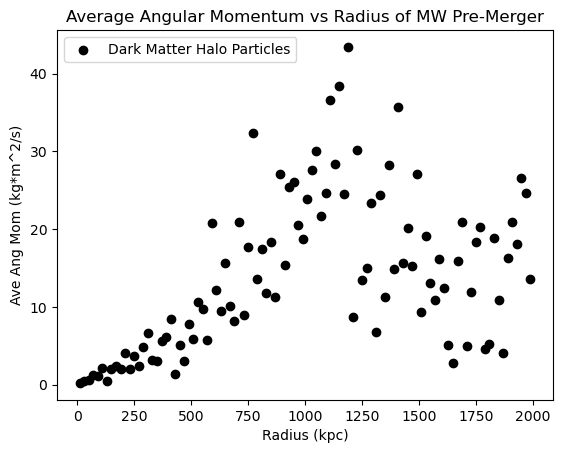

In [245]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

#Plotting Ave Ang Mom for MW Pre Merger:

#creating an array of radii so that historgram bins are centered
step = 20
r_vir_MW = 2000 
start = step/2
end = r_vir_MW + start
radii = np.arange(start, end, step=step)

#creating MW pre merger plot
fig, ax = plt.subplots()
aam_MW = np.sqrt(AngMomMW[:,0]**2 + AngMomMW[:,1]**2 + AngMomMW[:,2]**2)
ax.scatter(radii, aam_MW, label="Dark Matter Halo Particles", color="black")

"""
#Curve of best fit function
def curve_best_fit(x, a, b, c):
    return a*np.exp(-(x-b)**2 / c)

#Fitting the exponential model to the data
popt, pcov = curve_fit(curve_best_fit, radii, aam_MW)
x_fit = np.linspace(min(radii), max(radii), 400) # Generating x values for the curve of best fit
y_fit = curve_best_fit(x_fit, *popt) #Generating y values
ax.plot(x_fit, y_fit, 'r-', label='Best Fit Curve') #Adding curve of best fit to the plot 
"""

plt.title("Average Angular Momentum vs Radius of MW Pre-Merger")
ax.set_xlabel("Radius (kpc)")
ax.set_ylabel("Ave Ang Mom (kg*m^2/s)")
plt.legend()
plt.show()
#Ang mom increases, then decreases then increases

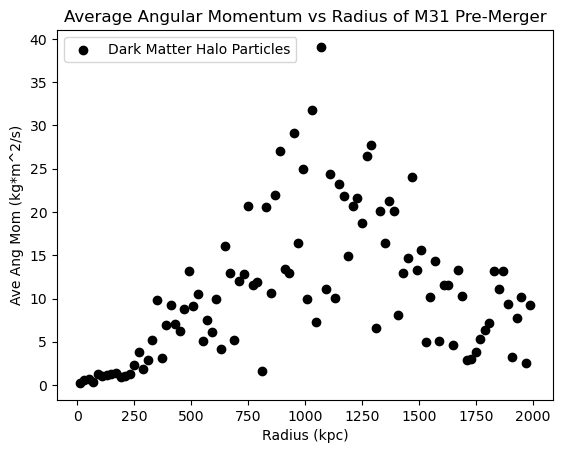

In [241]:
#Plotting Ave Ang Mom for M31 Pre Merger:

#creating an array of radii so that historgram bins are centered
radii = np.arange(start, end, step=step)

#creating MW pre merger plot
fig, ax = plt.subplots()
aam_M31 = np.sqrt(AngMomM31[:,0]**2 + AngMomM31[:,1]**2 + AngMomM31[:,2]**2)
ax.scatter(radii, aam_M31, label="Dark Matter Halo Particles", color="black")

'''
# Fit the model to the data
popt, pcov = curve_fit(curve_best_fit, radii, aam_M31)
x_fit = np.linspace(min(radii), max(radii), 400) # Generating x values for the curve of best fit and calculating y values
y_fit = curve_best_fit(x_fit, *popt)
ax.plot(x_fit, y_fit, 'r-', label='Best Fit Curve')  # Add the curve of best fit to the plot
'''

plt.title("Average Angular Momentum vs Radius of M31 Pre-Merger")
ax.set_xlabel("Radius (kpc)")
ax.set_ylabel("Ave Ang Mom (kg*m^2/s)")
plt.legend()
plt.show()
#Ang mom increases, then decreases then increases